# AI-FDS Final Prototype Evidence Notebook

This notebook documents the final AI-FDS prototype as an executable evidence report. It is written for reviewers, vigilators, and future maintainers who need to understand what was built, which datasets and training principles shaped the models, which files own the behavior, and where the prototype boundaries are.

The pattern is simple: explain the step, run a small verification cell, show the result as a table or chart, then connect the result back to the source file that owns the behavior.


## 3.0 METHODOLOGY

### 3.1 Project Flow Overview

#### 3.1.1 Evidence Notebook Pattern

This notebook follows a Kaggle-style evidence flow while staying appropriate for a dashboard prototype:

- Stage the work from project scope to data preparation, training rationale, model evidence, source traceability, report generation, and reviewer-facing limitations.
- Use verification gates after important stages so a reader can see what passed without opening every source file.
- Use saved metrics and artifacts instead of retraining models in the notebook.
- Show charts for data balance, model comparison, confusion matrices, ROC curves, and audio behavior feature importance.
- Show selective source excerpts rather than entire Python files.

The Capstone 1 report was used only as outdated reference context for methodology themes to preserve: Machine Learning Development Lifecycle (MLLC), dataset purpose, preprocessing, model justification, evaluation metrics, Late Fusion-style evidence thinking, and student-facing explainability.


In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "app" / "main.py").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find the AI-FDS project root.")


ROOT = find_project_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


def project_path(relative_path: str) -> Path:
    return ROOT / relative_path


def read_text(relative_path: str) -> str:
    return project_path(relative_path).read_text(encoding="utf-8")


def load_json(relative_path: str) -> dict[str, object]:
    return json.loads(read_text(relative_path))


def file_size_kb(path: Path) -> float:
    return round(path.stat().st_size / 1024, 1) if path.exists() and path.is_file() else 0.0


def ready_label(condition: bool) -> str:
    return "PASS" if condition else "MISSING"


def all_status_pass(frame: pd.DataFrame, status_column: str = "Status") -> bool:
    return status_column in frame.columns and set(frame[status_column].astype(str)) <= {"PASS"}


pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CBD5E1",
    "axes.labelcolor": "#0F172A",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

display(Markdown(f"Project root detected: `{ROOT}`"))


Project root detected: `C:\Users\user\Documents\Codex\ai-scam-detector`

### 3.2 Phase 1: Business Requirements

#### 3.2.1 Prototype Scope and Routing Verification

This section merges the previous scope, routing, and dashboard verification sections. The goal is to prove the current final surface in one place: two top-level pages, with three Detection Center tabs feeding saved evidence into the AI Report Generator.

```mermaid
flowchart LR
    A["app/main.py"] --> B["Detection Center"]
    A --> C["AI Report Generator"]
    B --> D["Email and message tab"]
    B --> E["Transcript and uploaded audio tab"]
    B --> F["Phone number tab"]
    D --> G["Saved evidence history"]
    E --> G
    F --> G
    G --> C
    C --> H["TXT / PDF / DOCX exports"]
```


In [2]:
def function_names(relative_path: str) -> set[str]:
    tree = ast.parse(read_text(relative_path), filename=relative_path)
    return {node.name for node in ast.walk(tree) if isinstance(node, ast.FunctionDef)}


def assigned_dict_keys(relative_path: str, variable_name: str) -> list[str]:
    tree = ast.parse(read_text(relative_path), filename=relative_path)
    keys: list[str] = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Assign):
            target_names = [target.id for target in node.targets if isinstance(target, ast.Name)]
            if variable_name in target_names and isinstance(node.value, ast.Dict):
                keys.extend(str(key.value) for key in node.value.keys if isinstance(key, ast.Constant))
    return keys


core_paths = [
    ("Streamlit entry point", "app/main.py"),
    ("Detection Center page", "app/detection_center_page.py"),
    ("Email tab", "app/email_tab.py"),
    ("Transcript and audio tab", "app/transcript_tab.py"),
    ("Phone tab", "app/phone_tab.py"),
    ("Report generator page", "app/report_page.py"),
    ("Report builder", "src/reporting/report_builder.py"),
    ("Phone provider rules", "app/phone_tab.py"),
    ("Live audio analysis", "src/audio/live_audio_analysis.py"),
]
core_path_df = pd.DataFrame([
    {"Role": role, "File": rel_path, "Status": ready_label(project_path(rel_path).exists()), "Size KB": file_size_kb(project_path(rel_path))}
    for role, rel_path in core_paths
])

required_functions = [
    ("app/main.py", "main", "Application entry point"),
    ("app/detection_center_page.py", "render_detection_center_page", "Three-tab detection surface"),
    ("app/email_tab.py", "render_email_tab", "Email/message analysis UI"),
    ("app/transcript_tab.py", "render_transcript_tab", "Transcript/audio analysis UI"),
    ("app/phone_tab.py", "render_phone_risk_page", "Phone reputation UI"),
    ("app/report_page.py", "render_report_page", "Report generator UI"),
    ("src/audio/live_audio_analysis.py", "analyse_live_chunk", "Combined audio/transcript scoring"),
    ("app/phone_tab.py", "_build_phone_investigation", "Veriphone.io and PenipuMY provider evidence collection"),
    ("app/phone_tab.py", "_build_phone_assessment", "Transparent phone evidence-concern scoring"),
    ("src/reporting/report_builder.py", "build_report", "TXT/PDF/DOCX export builder"),
]
function_df = pd.DataFrame([
    {"File": rel_path, "Expected function": function_name, "Purpose": purpose, "Status": ready_label(function_name in function_names(rel_path))}
    for rel_path, function_name, purpose in required_functions
])

pages = assigned_dict_keys("app/main.py", "PAGES")
detection_tabs = sorted(set(re.findall(r'active_tab == "([^"]+)"', read_text("app/detection_center_page.py"))))
dashboard_gate_df = pd.DataFrame([
    {"Gate": "Two active top-level pages", "Expected": "AI Report Generator, Detection Center", "Observed": ", ".join(sorted(pages)), "Status": ready_label(set(pages) == {"Detection Center", "AI Report Generator"})},
    {"Gate": "Three Detection Center tabs", "Expected": "email, phone, transcript", "Observed": ", ".join(detection_tabs), "Status": ready_label(set(detection_tabs) == {"email", "transcript", "phone"})},
])

display(Markdown("### Core source files"))
display(core_path_df)
display(Markdown("### Required function checks"))
display(function_df)
display(Markdown("### Scope verification gate"))
display(dashboard_gate_df)


### Core source files

,Role,File,Status,Size KB
0,Streamlit entry point,app/main.py,PASS,2.2
1,Detection Center page,app/detection_center_page.py,PASS,1.1
2,Email tab,app/email_tab.py,PASS,69.5
3,Transcript and audio tab,app/transcript_tab.py,PASS,116.1
4,Phone tab,app/phone_tab.py,PASS,107.3
5,Report generator page,app/report_page.py,PASS,17.3
6,Report builder,src/reporting/report_builder.py,PASS,36.8
7,Phone provider rules,app/phone_tab.py,PASS,107.3
8,Live audio analysis,src/audio/live_audio_analysis.py,PASS,31.9


### Required function checks

,File,Expected function,Purpose,Status
0,app/main.py,main,Application entry point,PASS
1,app/detection_center_page.py,render_detection_center_page,Three-tab detection surface,PASS
2,app/email_tab.py,render_email_tab,Email/message analysis UI,PASS
3,app/transcript_tab.py,render_transcript_tab,Transcript/audio analysis UI,PASS
4,app/phone_tab.py,render_phone_risk_page,Phone reputation UI,PASS
5,app/report_page.py,render_report_page,Report generator UI,PASS
6,src/audio/live_audio_analysis.py,analyse_live_chunk,Combined audio/transcript scoring,PASS
7,app/phone_tab.py,_build_phone_investigation,Veriphone.io and PenipuMY provider evidence collection,PASS
8,app/phone_tab.py,_build_phone_assessment,Transparent phone evidence-concern scoring,PASS
9,src/reporting/report_builder.py,build_report,TXT/PDF/DOCX export builder,PASS


### Scope verification gate

,Gate,Expected,Observed,Status
0,Two active top-level pages,"AI Report Generator, Detection Center","AI Report Generator, Detection Center",PASS
1,Three Detection Center tabs,"email, phone, transcript","email, phone, transcript",PASS


### 3.3 Phase 2: Data Collection

#### 3.3.1 Dataset Purpose and Preparation Rationale

This section adds the missing training-methodology context from the older report and updates it to match the final prototype. The project follows a Machine Learning Development Lifecycle (MLLC) idea: define the user problem, choose data that matches each evidence type, preprocess into consistent features, train/evaluate models, then deploy the useful outputs in Streamlit with explanations, Late Fusion-style combined evidence, and report generation.

The key principle is that each dataset has a job:

- Email data teaches the system phishing/legitimate text patterns.
- Transcript data teaches scam intent from conversation text, even when audio is unavailable.
- ASVspoof audio data teaches bonafide vs spoofed/generated voice characteristics.
- Phone caller checks use API-derived provider evidence rather than a trained phone ML classifier: Veriphone.io returns carrier/line metadata, PenipuMY returns scam-report and reputation fields, and the dashboard applies transparent rule weights to the returned evidence.


In [3]:
DATASETS = [
    ("Email processed dataset", "data/processed/email/email_dataset.csv", ["label"], "SpamAssassin, Enron legitimate mail, and phishing 2026 sources", "Train phishing/legitimate message classifiers."),
    ("Transcript processed dataset", "data/processed/transcript/transcript_dataset.csv", ["label"], "Call Transcripts Scam Determinations and supported transcript sources", "Train scam-intent classifiers for call or meeting text."),
    ("Phone processed dataset", "data/processed/phone/phone_dataset.csv", ["record_type", "business_tier", "source"], "Local/demo reputation records and provider-style metadata fields", "Support deterministic risk rules and demos; not ML training."),
    ("Audio label index", "data/processed/audio/labels.csv", ["label", "split"], "Balanced ASVspoof 2019 LA subset", "Train and validate bonafide vs spoof audio classifiers."),
    ("Demo email records", "data/demo/demo_emails.csv", ["label", "prediction"], "Curated demo samples", "Provide repeatable UI demonstration examples."),
    ("Demo transcript records", "data/demo/demo_transcripts.csv", ["label", "prediction"], "Curated demo samples", "Provide repeatable transcript demonstration examples."),
    ("Demo phone records", "data/demo/demo_phone_numbers.csv", ["risk_level", "record_type", "source"], "Curated demo samples", "Provide repeatable phone lookup examples."),
]


def summarize_csv(relative_path: str, candidate_columns: list[str]) -> dict[str, object]:
    path = project_path(relative_path)
    if not path.exists():
        return {"File": relative_path, "Rows": 0, "Columns": 0, "Size KB": 0.0, "Distribution column": "-", "Distribution": "missing file", "Status": "MISSING"}
    frame = pd.read_csv(path)
    distribution_column = "-"
    distribution_text = "-"
    for column in candidate_columns:
        if column in frame.columns:
            counts = frame[column].fillna("<missing>").astype(str).value_counts().head(8)
            distribution_column = column
            distribution_text = "; ".join(f"{key}: {value}" for key, value in counts.items())
            break
    return {
        "File": relative_path,
        "Rows": f"{len(frame):,}",
        "Columns": len(frame.columns),
        "Size KB": file_size_kb(path),
        "Distribution column": distribution_column,
        "Distribution": distribution_text,
        "Status": "PASS",
    }


data_readiness_df = pd.DataFrame([
    {
        "Dataset": label,
        "Source purpose": purpose,
        "Chosen because": reason,
        **summarize_csv(path, columns),
    }
    for label, path, columns, reason, purpose in DATASETS
])
display(data_readiness_df)


,Dataset,Source purpose,Chosen because,File,Rows,Columns,Size KB,Distribution column,Distribution,Status
0,Email processed dataset,Train phishing/legitimate message classifiers.,"SpamAssassin, Enron legitimate mail, and phishing 2026 sources",data/processed/email/email_dataset.csv,"33,884",4,46240.3,label,0: 26592; 1: 7292,PASS
1,Transcript processed dataset,Train scam-intent classifiers for call or meeting text.,Call Transcripts Scam Determinations and supported transcript sources,data/processed/transcript/transcript_dataset.csv,578,3,104.7,label,0: 322; 1: 256,PASS
2,Phone processed dataset,Support deterministic risk rules and demos; not ML training.,Local/demo reputation records and provider-style metadata fields,data/processed/phone/phone_dataset.csv,0,13,0.2,record_type,,PASS
3,Audio label index,Train and validate bonafide vs spoof audio classifiers.,Balanced ASVspoof 2019 LA subset,data/processed/audio/labels.csv,"2,600",7,174.2,label,spoof: 1300; bonafide: 1300,PASS
4,Demo email records,Provide repeatable UI demonstration examples.,Curated demo samples,data/demo/demo_emails.csv,5,4,1.0,label,Suspicious: 3; Legitimate: 2,PASS
5,Demo transcript records,Provide repeatable transcript demonstration examples.,Curated demo samples,data/demo/demo_transcripts.csv,5,4,1.0,label,Scam: 3; Non-scam: 2,PASS
6,Demo phone records,Provide repeatable phone lookup examples.,Curated demo samples,data/demo/demo_phone_numbers.csv,5,5,0.6,source,TEMPORARY_SYNTHETIC_DEMO_DATA_REMOVE_AFTER_OFFICIAL_DATASET_INSERTION: 5,PASS


### 3.4 Phase 3: Data Cleaning and Preprocessing

#### 3.4.1 Backend Preparation and Training Commands

Some important work happens in terminal scripts rather than inside the Streamlit dashboard. This section documents the commands and the expected terminal evidence so a reviewer understands what was supposed to happen behind the UI.

The notebook does not rerun these commands because training can be slow and may depend on local raw datasets or cached transformer checkpoints. Instead, it checks that the command wrappers and saved outputs exist, then summarizes the expected logs.


In [4]:
training_commands = [
    ("Environment check", "py scripts/00_setup_check.py", "scripts/00_setup_check.py", "Checks local dependencies and folder readiness.", "Dependency and environment status lines."),
    ("Prepare email dataset", "py scripts/01_prepare_email_dataset.py", "scripts/01_prepare_email_dataset.py", "Loads SpamAssassin, Enron, and phishing CSV data into a processed text dataset.", "Dataset prepared successfully; total rows; label counts; source counts."),
    ("Prepare transcript dataset", "py scripts/02_prepare_transcript_dataset.py", "scripts/02_prepare_transcript_dataset.py", "Builds supervised transcript rows and separates unlabeled rows for review.", "Transcript dataset prepared; samples; label counts; source counts; unlabeled review rows."),
    ("Prepare audio dataset", "py scripts/03_prepare_audio_dataset.py", "scripts/03_prepare_audio_dataset.py", "Samples a balanced ASVspoof train/dev subset and writes labels.csv.", "Preparing train/dev split; copied files; final counts by split and label."),
    ("Train email models", "py scripts/04_train_email_model.py", "scripts/04_train_email_model.py", "Trains TF-IDF email classifiers and saves model/metric artifacts.", "Dataset loaded; vectorizing text; training model names; Accuracy/Precision/Recall/F1/ROC-AUC; top benchmark; saved paths."),
    ("Train transcript models", "py scripts/05_train_transcript_model.py", "scripts/05_train_transcript_model.py", "Trains TF-IDF transcript classifiers and optionally transformer models.", "Transcript dataset loaded; vocabulary size; metrics; recommended model; vectorizer and metric paths."),
    ("Train audio MFCC model", "py scripts/06_train_audio_model.py", "scripts/06_train_audio_model.py", "Extracts MFCC/statistical features and trains calibrated SVM.", "Loading audio features; train/dev samples; feature dimension; metrics; model and metric paths."),
    ("Train audio behavior model", "py scripts/07_train_audio_behavior_model.py", "scripts/07_train_audio_behavior_model.py", "Extracts behavior metadata and trains Random Forest.", "Loading behavioral audio features; feature dimension; metrics; feature importances; saved paths."),
]

command_df = pd.DataFrame([
    {
        "Stage": stage,
        "Command": command,
        "Wrapper exists": ready_label(project_path(wrapper).exists()),
        "Purpose": purpose,
        "Expected terminal evidence": expected,
    }
    for stage, command, wrapper, purpose, expected in training_commands
])
display(command_df)


,Stage,Command,Wrapper exists,Purpose,Expected terminal evidence
0,Environment check,py scripts/00_setup_check.py,PASS,Checks local dependencies and folder readiness.,Dependency and environment status lines.
1,Prepare email dataset,py scripts/01_prepare_email_dataset.py,PASS,"Loads SpamAssassin, Enron, and phishing CSV data into a processed text dataset.",Dataset prepared successfully; total rows; label counts; source counts.
2,Prepare transcript dataset,py scripts/02_prepare_transcript_dataset.py,PASS,Builds supervised transcript rows and separates unlabeled rows for review.,Transcript dataset prepared; samples; label counts; source counts; unlabeled review rows.
3,Prepare audio dataset,py scripts/03_prepare_audio_dataset.py,PASS,Samples a balanced ASVspoof train/dev subset and writes labels.csv.,Preparing train/dev split; copied files; final counts by split and label.
4,Train email models,py scripts/04_train_email_model.py,PASS,Trains TF-IDF email classifiers and saves model/metric artifacts.,Dataset loaded; vectorizing text; training model names; Accuracy/Precision/Recall/F1/ROC-AUC; top benchmark; saved paths.
5,Train transcript models,py scripts/05_train_transcript_model.py,PASS,Trains TF-IDF transcript classifiers and optionally transformer models.,Transcript dataset loaded; vocabulary size; metrics; recommended model; vectorizer and metric paths.
6,Train audio MFCC model,py scripts/06_train_audio_model.py,PASS,Extracts MFCC/statistical features and trains calibrated SVM.,Loading audio features; train/dev samples; feature dimension; metrics; model and metric paths.
7,Train audio behavior model,py scripts/07_train_audio_behavior_model.py,PASS,Extracts behavior metadata and trains Random Forest.,Loading behavioral audio features; feature dimension; metrics; feature importances; saved paths.


### 3.5 Phase 4: Exploratory Data Analysis (EDA)

#### 3.5.1 Processed Data Distribution Charts


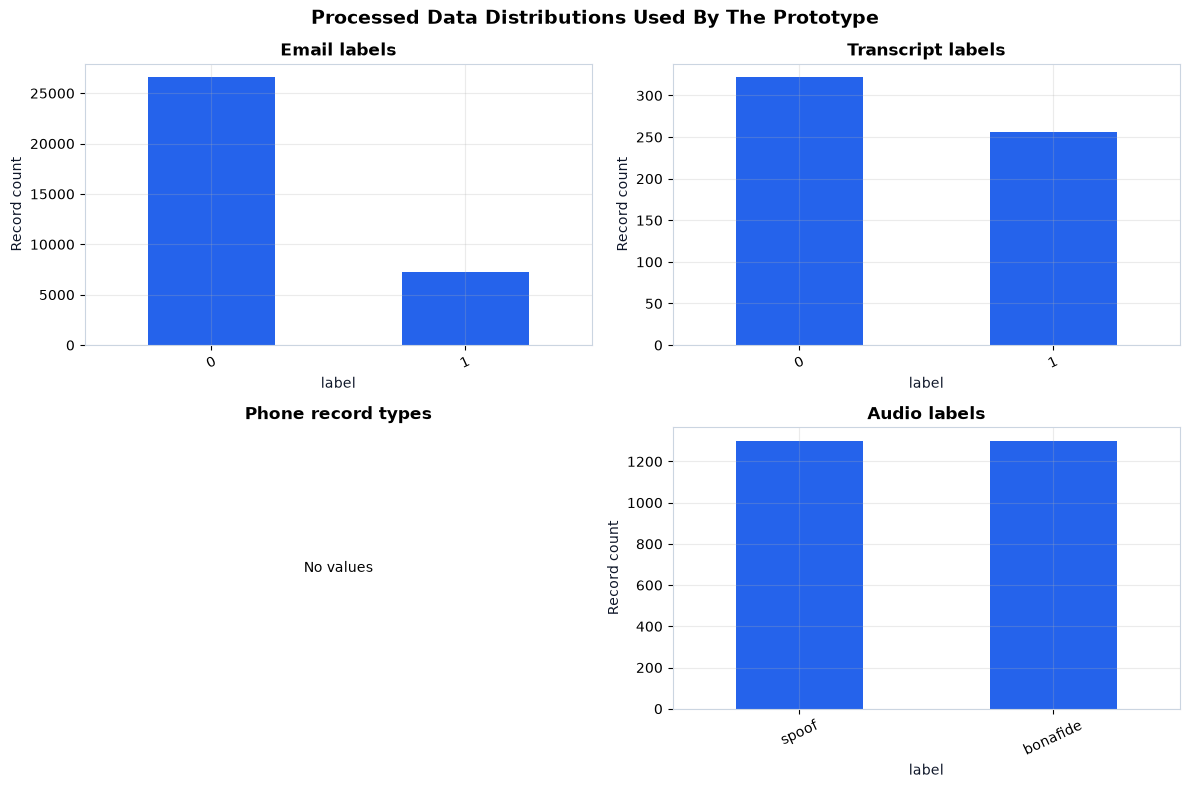

In [5]:
chart_specs = [
    ("Email labels", "data/processed/email/email_dataset.csv", "label"),
    ("Transcript labels", "data/processed/transcript/transcript_dataset.csv", "label"),
    ("Phone record types", "data/processed/phone/phone_dataset.csv", "record_type"),
    ("Audio labels", "data/processed/audio/labels.csv", "label"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (title, relative_path, column) in zip(axes.flatten(), chart_specs):
    path = project_path(relative_path)
    if not path.exists():
        ax.text(0.5, 0.5, "Missing file", ha="center", va="center")
        ax.axis("off")
        ax.set_title(title)
        continue
    frame = pd.read_csv(path)
    if column not in frame.columns:
        ax.text(0.5, 0.5, f"No `{column}` column", ha="center", va="center")
        ax.axis("off")
        ax.set_title(title)
        continue
    counts = frame[column].dropna().astype(str)
    counts = counts[counts.str.strip() != ""].value_counts().head(8)
    if counts.empty:
        ax.text(0.5, 0.5, "No values", ha="center", va="center")
        ax.axis("off")
        ax.set_title(title)
        continue
    counts.plot(kind="bar", ax=ax, color="#2563EB")
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Record count")
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Processed Data Distributions Used By The Prototype", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.6 Phase 5: Model Selection and Training

#### 3.6.1 Training Split and Feature Engineering Audit

The final training logic uses different split strategies by modality:

- Email and transcript text use a stratified 80/20 train/test split. Stratification keeps the label ratio similar in training and test data, which makes evaluation more honest.
- Audio uses the ASVspoof train/dev protocol style, then the local preprocessor samples balanced bonafide/spoof subsets. This is not an 80/20 split.
- Phone caller checks do not have a train/test split because this workflow is not trained locally. It collects live provider evidence from Veriphone.io and PenipuMY, then applies deterministic evidence-concern rules.

Feature engineering is also modality-specific: TF-IDF for text, MFCC/statistical features for audio, behavior metadata for secondary audio review, and API-derived provider fields for phone caller evidence.


In [6]:
METRIC_FILES = {
    "Email": "reports/metrics/email_model_metrics.json",
    "Transcript": "reports/metrics/transcript_model_metrics.json",
    "Audio MFCC": "reports/metrics/audio_model_metrics.json",
    "Audio behavior": "reports/metrics/audio_behavior_metrics.json",
}

email_metrics = load_json(METRIC_FILES["Email"])
transcript_metrics = load_json(METRIC_FILES["Transcript"])
audio_metrics = load_json(METRIC_FILES["Audio MFCC"])
audio_behavior_metrics = load_json(METRIC_FILES["Audio behavior"])

split_audit_df = pd.DataFrame([
    {
        "Channel": "Email",
        "Split principle": "Stratified 80/20 train/test",
        "Observed split": f"{email_metrics.get('train_samples'):,} train / {email_metrics.get('test_samples'):,} test",
        "Source proof": "src/training/email_trainer.py uses train_test_split(test_size=0.2, stratify=df['label'])",
        "Why it matters": "Preserves class balance while holding out unseen examples for metrics.",
    },
    {
        "Channel": "Transcript",
        "Split principle": "Stratified 80/20 train/test",
        "Observed split": f"{transcript_metrics.get('train_samples'):,} train / {transcript_metrics.get('test_samples'):,} test",
        "Source proof": "src/training/transcript_trainer.py uses train_test_split(test_size=0.2, stratify=df['label'])",
        "Why it matters": "Keeps legitimate/suspicious proportions stable despite the smaller dataset.",
    },
    {
        "Channel": "Audio MFCC",
        "Split principle": "ASVspoof train/dev protocol subset",
        "Observed split": f"{audio_metrics.get('train_samples'):,} train / {audio_metrics.get('dev_samples'):,} dev",
        "Source proof": "src/preprocessing/audio_preprocessor.py samples train and dev protocol files separately.",
        "Why it matters": "Keeps audio validation aligned to the source dataset's train/dev structure.",
    },
    {
        "Channel": "Audio behavior",
        "Split principle": "Same ASVspoof train/dev subset",
        "Observed split": f"{audio_behavior_metrics.get('train_samples'):,} train / {audio_behavior_metrics.get('dev_samples'):,} dev",
        "Source proof": "src/training/audio_behavior_trainer.py loads split == 'train' and split == 'dev'.",
        "Why it matters": "Evaluates behavior metadata on the same held-out dev examples.",
    },
    {
        "Channel": "Phone",
        "Split principle": "No ML split",
        "Observed split": "No local training split; live provider evidence is interpreted at runtime",
        "Source proof": "app/phone_tab.py::_build_phone_investigation and app/phone_tab.py::_build_phone_assessment",
        "Why it matters": "Phone concern comes from Veriphone.io/PenipuMY API fields and transparent weights, not locally learned caller-risk values.",
    },
])

feature_audit_df = pd.DataFrame([
    {
        "Channel": "Email",
        "Feature strategy": "TF-IDF word n-grams",
        "Observed details": f"ngram_range={tuple(email_metrics['vectorizer']['ngram_range'])}, max_features={email_metrics['vectorizer']['max_features']:,}, vocabulary={email_metrics['vectorizer']['vocabulary_size']:,}",
        "Reason": "Efficiently captures phishing words and phrases while remaining lightweight for a student-facing app.",
    },
    {
        "Channel": "Transcript",
        "Feature strategy": "TF-IDF word n-grams plus optional transformer context",
        "Observed details": f"ngram_range={tuple(transcript_metrics['vectorizer']['ngram_range'])}, max_features={transcript_metrics['vectorizer']['max_features']:,}, vocabulary={transcript_metrics['vectorizer']['vocabulary_size']:,}",
        "Reason": "Classic models are fast and explainable; DistilBERT adds contextual language understanding when available.",
    },
    {
        "Channel": "Audio MFCC",
        "Feature strategy": "MFCC, delta MFCC, spectral, energy, and duration statistics",
        "Observed details": f"sample_rate={audio_metrics['sample_rate']:,}, n_mfcc={audio_metrics['n_mfcc']}, feature_dimension={audio_metrics['feature_dimension']}",
        "Reason": "MFCC-style features are common for speaker/audio authenticity tasks and avoid raw waveform model complexity.",
    },
    {
        "Channel": "Audio behavior",
        "Feature strategy": "Speech activity, silence, energy, spectral, pause, and speech-rate metadata",
        "Observed details": f"feature_dimension={audio_behavior_metrics['feature_dimension']}",
        "Reason": "Adds an interpretable secondary signal for reviewing voice behavior, not forensic identity proof.",
    },
])

display(Markdown("### Split strategy audit"))
display(split_audit_df)
display(Markdown("### Feature engineering audit"))
display(feature_audit_df)


### Split strategy audit

,Channel,Split principle,Observed split,Source proof,Why it matters
0,Email,Stratified 80/20 train/test,"27,107 train / 6,777 test","src/training/email_trainer.py uses train_test_split(test_size=0.2, stratify=df['label'])",Preserves class balance while holding out unseen examples for metrics.
1,Transcript,Stratified 80/20 train/test,462 train / 116 test,"src/training/transcript_trainer.py uses train_test_split(test_size=0.2, stratify=df['label'])",Keeps legitimate/suspicious proportions stable despite the smaller dataset.
2,Audio MFCC,ASVspoof train/dev protocol subset,"2,000 train / 600 dev",src/preprocessing/audio_preprocessor.py samples train and dev protocol files separately.,Keeps audio validation aligned to the source dataset's train/dev structure.
3,Audio behavior,Same ASVspoof train/dev subset,"2,000 train / 600 dev",src/training/audio_behavior_trainer.py loads split == 'train' and split == 'dev'.,Evaluates behavior metadata on the same held-out dev examples.
4,Phone,No ML split,No local training split; live provider evidence is interpreted at runtime,app/phone_tab.py::_build_phone_investigation and app/phone_tab.py::_build_phone_assessment,"Phone concern comes from Veriphone.io/PenipuMY API fields and transparent weights, not locally learned caller-risk values."


### Feature engineering audit

,Channel,Feature strategy,Observed details,Reason
0,Email,TF-IDF word n-grams,"ngram_range=(1, 3), max_features=15,000, vocabulary=15,000",Efficiently captures phishing words and phrases while remaining lightweight for a student-facing app.
1,Transcript,TF-IDF word n-grams plus optional transformer context,"ngram_range=(1, 3), max_features=20,000, vocabulary=1,310",Classic models are fast and explainable; DistilBERT adds contextual language understanding when available.
2,Audio MFCC,"MFCC, delta MFCC, spectral, energy, and duration statistics","sample_rate=16,000, n_mfcc=40, feature_dimension=251",MFCC-style features are common for speaker/audio authenticity tasks and avoid raw waveform model complexity.
3,Audio behavior,"Speech activity, silence, energy, spectral, pause, and speech-rate metadata",feature_dimension=13,"Adds an interpretable secondary signal for reviewing voice behavior, not forensic identity proof."


#### 3.6.2 Model Artifact Readiness, Selection Logic, and Saved Metrics

This merged section combines artifact readiness, model-selection logic, and metric interpretation. It answers three reviewer questions:

- Are the expected artifacts available?
- Which model families were trained or used, and why?
- What do the saved metrics say about the current prototype?


In [7]:
artifact_groups = {
    "Email models": [
        "models/email_vectorizer.pkl", "models/email_nb.pkl", "models/email_dt.pkl",
        "models/email_svm.pkl", "models/email_rf.pkl", "models/email_xgb.pkl", "models/email_best.pkl",
    ],
    "Transcript models": [
        "models/transcript_vectorizer.pkl", "models/transcript_nb.pkl",
        "models/transcript_svm.pkl", "models/transcript_distilbert",
    ],
    "Audio models": ["models/audio_svm.pkl", "models/audio_behavior_rf.pkl"],
    "Metric reports": list(METRIC_FILES.values()),
}

artifact_df = pd.DataFrame([
    {
        "Group": group,
        "Artifact": artifact,
        "Status": ready_label(project_path(artifact).exists()),
        "Kind": "directory" if project_path(artifact).is_dir() else "file",
        "Size KB": file_size_kb(project_path(artifact)) if project_path(artifact).is_file() else "-",
    }
    for group, artifacts in artifact_groups.items()
    for artifact in artifacts
])
display(artifact_df)


,Group,Artifact,Status,Kind,Size KB
0,Email models,models/email_vectorizer.pkl,PASS,file,587.5
1,Email models,models/email_nb.pkl,PASS,file,469.5
2,Email models,models/email_dt.pkl,PASS,file,12.6
3,Email models,models/email_svm.pkl,PASS,file,588.8
4,Email models,models/email_rf.pkl,PASS,file,17433.1
5,Email models,models/email_xgb.pkl,PASS,file,293.1
6,Email models,models/email_best.pkl,PASS,file,588.8
7,Transcript models,models/transcript_vectorizer.pkl,PASS,file,53.8
8,Transcript models,models/transcript_nb.pkl,PASS,file,41.7
9,Transcript models,models/transcript_svm.pkl,PASS,file,54.1


In [8]:
def as_float(value: object) -> float | None:
    try:
        if value is None:
            return None
        number = float(value)
        return number if math.isfinite(number) else None
    except (TypeError, ValueError):
        return None


def metric_rows_from_json(channel: str, relative_path: str) -> list[dict[str, object]]:
    data = load_json(relative_path)
    selected_name = data.get("best_model") or data.get("recommended_model") or data.get("top_validation_model")
    rows: list[dict[str, object]] = []
    if isinstance(data.get("models"), dict):
        for model_name, metrics in data["models"].items():
            rows.append({
                "Channel": channel,
                "Model": model_name,
                "Selected or recommended": "Yes" if str(model_name) == str(selected_name) else "No",
                "Accuracy": as_float(metrics.get("accuracy")),
                "Precision": as_float(metrics.get("precision")),
                "Recall": as_float(metrics.get("recall")),
                "F1": as_float(metrics.get("f1")),
                "ROC-AUC": as_float(metrics.get("roc_auc")),
                "Train seconds": as_float(metrics.get("training_time_seconds") or metrics.get("training_seconds")),
                "Metric file": relative_path,
            })
    else:
        metrics = data.get("metrics", {})
        rows.append({
            "Channel": channel,
            "Model": data.get("model", Path(relative_path).stem),
            "Selected or recommended": "Yes",
            "Accuracy": as_float(metrics.get("accuracy")),
            "Precision": as_float(metrics.get("precision")),
            "Recall": as_float(metrics.get("recall")),
            "F1": as_float(metrics.get("f1")),
            "ROC-AUC": as_float(metrics.get("roc_auc")),
            "Train seconds": as_float(data.get("training_time_seconds") or data.get("training_seconds")),
            "Metric file": relative_path,
        })
    return rows


metric_df = pd.DataFrame([
    row
    for channel, relative_path in METRIC_FILES.items()
    for row in metric_rows_from_json(channel, relative_path)
])
metric_display_df = metric_df.copy()
for column in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Train seconds"]:
    metric_display_df[column] = metric_display_df[column].map(lambda value: "-" if pd.isna(value) else f"{value:.3f}")
display(metric_display_df)


,Channel,Model,Selected or recommended,Accuracy,Precision,Recall,F1,ROC-AUC,Train seconds,Metric file
0,Email,Naive Bayes,No,0.988,0.997,0.945,0.970,1.000,0.035,reports/metrics/email_model_metrics.json
1,Email,Decision Tree,No,0.981,0.935,0.979,0.956,0.994,16.030,reports/metrics/email_model_metrics.json
2,Email,SVM,Yes,0.998,0.995,0.995,0.995,1.000,2.889,reports/metrics/email_model_metrics.json
3,Email,Random Forest,No,0.993,0.976,0.992,0.984,1.000,19.207,reports/metrics/email_model_metrics.json
4,Email,XGBoost,No,0.997,0.992,0.992,0.992,1.000,144.025,reports/metrics/email_model_metrics.json
5,Transcript,Naive Bayes,No,0.802,0.850,0.667,0.747,0.912,0.004,reports/metrics/transcript_model_metrics.json
6,Transcript,SVM,No,0.819,0.812,0.765,0.788,0.909,0.078,reports/metrics/transcript_model_metrics.json
7,Transcript,DistilBERT,Yes,0.836,0.864,0.745,0.800,0.913,590.212,reports/metrics/transcript_model_metrics.json
8,Audio MFCC,Calibrated SVM with MFCC/statistical audio features,Yes,0.937,0.897,0.987,0.940,0.994,0.404,reports/metrics/audio_model_metrics.json
9,Audio behavior,Random Forest on audio behavior metadata,Yes,0.822,0.841,0.793,0.816,0.879,0.650,reports/metrics/audio_behavior_metrics.json


In [9]:
def best_metric_summary(channel: str) -> str:
    rows = metric_df[metric_df["Channel"] == channel].dropna(subset=["F1"])
    if rows.empty:
        return "No saved F1 metric"
    selected = rows[rows["Selected or recommended"] == "Yes"]
    row = (selected if not selected.empty else rows.sort_values("F1", ascending=False)).iloc[0]
    return f"{row['Model']} (F1 {row['F1']:.3f}, ROC-AUC {row['ROC-AUC']:.3f})"


model_selection_df = pd.DataFrame([
    {
        "Channel": "Email / message",
        "Runtime owner": "app/email_tab.py::MODEL_FILES",
        "Training principle": "TF-IDF features with Naive Bayes, Decision Tree, SVM, Random Forest, and XGBoost baselines.",
        "Selection logic": "User can choose a trained classifier; SVM is the saved validation benchmark.",
        "Saved metric summary": best_metric_summary("Email"),
    },
    {
        "Channel": "Transcript text",
        "Runtime owner": "app/transcript_tab.py::TRANSCRIPT_MODEL_FILES",
        "Training principle": "TF-IDF NB/SVM plus optional DistilBERT fine-tuning.",
        "Selection logic": "User can choose NB, SVM, or DistilBERT; loader falls back to an available artifact if needed.",
        "Saved metric summary": best_metric_summary("Transcript"),
    },
    {
        "Channel": "Uploaded audio / voice",
        "Runtime owner": "src/audio/live_audio_analysis.py::analyse_live_chunk",
        "Training principle": "Calibrated SVM over MFCC/statistical audio features, plus behavior metadata RF.",
        "Selection logic": "Late Fusion-style averaging combines acoustic, behavioral, speech-quality, and transcript-risk signals.",
        "Saved metric summary": best_metric_summary("Audio MFCC"),
    },
    {
        "Channel": "Phone number",
        "Runtime owner": "app/phone_tab.py::_build_phone_investigation + _build_phone_assessment",
        "Training principle": "No ML training. Veriphone.io carrier/line metadata and PenipuMY scam-report/reputation fields are pulled from APIs.",
        "Selection logic": "Transparent evidence-concern weights convert provider fields into priority, score, explanation, and recommended action.",
        "Saved metric summary": "Rule based; no ML validation metric JSON expected",
    },
])
display(model_selection_df)


,Channel,Runtime owner,Training principle,Selection logic,Saved metric summary
0,Email / message,app/email_tab.py::MODEL_FILES,"TF-IDF features with Naive Bayes, Decision Tree, SVM, Random Forest, and XGBoost baselines.",User can choose a trained classifier; SVM is the saved validation benchmark.,"SVM (F1 0.995, ROC-AUC 1.000)"
1,Transcript text,app/transcript_tab.py::TRANSCRIPT_MODEL_FILES,TF-IDF NB/SVM plus optional DistilBERT fine-tuning.,"User can choose NB, SVM, or DistilBERT; loader falls back to an available artifact if needed.","DistilBERT (F1 0.800, ROC-AUC 0.913)"
2,Uploaded audio / voice,src/audio/live_audio_analysis.py::analyse_live_chunk,"Calibrated SVM over MFCC/statistical audio features, plus behavior metadata RF.","Late Fusion-style averaging combines acoustic, behavioral, speech-quality, and transcript-risk signals.","Calibrated SVM with MFCC/statistical audio features (F1 0.940, ROC-AUC 0.994)"
3,Phone number,app/phone_tab.py::_build_phone_investigation + _build_phone_assessment,No ML training. Veriphone.io carrier/line metadata and PenipuMY scam-report/reputation fields are pulled from APIs.,"Transparent evidence-concern weights convert provider fields into priority, score, explanation, and recommended action.",Rule based; no ML validation metric JSON expected



#### 3.6.3 From Training Output To Usable Dashboard Models

The training workflow should be read as a pipeline, not as a one-time notebook result:

1. **Prepare** raw or semi-structured evidence into processed datasets.
2. **Train** candidate models using the correct feature strategy for each modality.
3. **Evaluate** each candidate with held-out metrics such as accuracy, precision, recall, F1, ROC-AUC, confusion matrix, and feature importance where available.
4. **Save** the usable model artifacts, vectorizers, transformer folders, and metric JSON files into the project folders.
5. **Load** those saved artifacts inside the dashboard so users can run predictions without retraining during the demo.

This means the final prototype is not retraining models every time the Streamlit app opens. The dashboard uses the final saved artifacts and exposes their behavior through model menus, confidence scores, explanations, and report-ready history entries.



### 3.7 Phase 6: Detection System and Response

This phase explains how the prepared datasets, saved model artifacts, provider evidence, and rule-based logic become user-facing dashboard results. The purpose of this section is not only to prove source files exist, but to explain how a user action becomes a detection response and then report-ready evidence.

#### 3.7.1 Detection Center Runtime Flow

The Detection Center is the operational page where the reviewer chooses one of three evidence paths:

1. **Email and message tab:** the user provides message text or file content, selects/uses a saved text model, then receives a phishing or lower-risk result with supporting indicators.
2. **Transcript and uploaded audio tab:** the user provides transcript text or audio. Text is scored by saved transcript models, while audio can add voice-authenticity, behavior, and transcript-derived signals.
3. **Phone number tab:** the user provides a caller number and optional claimed identity. The dashboard collects provider evidence and applies transparent concern rules instead of training a phone model.

All three paths produce structured evidence that can be stored in history and later selected by the AI Report Generator.

#### 3.7.2 Evidence Strategy By Tab

| Detection area | Input accepted | Runtime method | Main output |
|---|---|---|---|
| Email/message | Email or message text | Saved trained text classifier and suspicious-content indicators | Prediction label, confidence, highlighted evidence, saved history row |
| Transcript text | Call transcript or extracted speech text | Saved transcript classifier or transformer artifact | Suspicious-risk result, confidence, explanation, saved history row |
| Uploaded/recorded audio | Voice clip or recording | Saved audio models plus transcript/speech-quality signals where available | Voice/transcript concern signals, combined educational risk, saved history row |
| Phone number | Caller number and optional claimed identity | Veriphone.io carrier metadata, PenipuMY reputation reports, and transparent evidence-concern rules | Concern priority, evidence score, provider status, recommended verification action |

#### 3.7.3 Runtime Model and Provider Loading

The dashboard separates trained AI artifacts from runtime evidence collection:

- Email, transcript, and audio workflows load saved model/vectorizer artifacts from the project folders.
- Metrics shown in the notebook come from saved JSON reports, not from retraining inside the notebook.
- Phone checks call configured providers at runtime because caller reputation can change and was not trained locally.
- If a model or provider is unavailable, the app should explain that limitation instead of pretending a result is stronger than it is.

#### 3.7.4 Result Explanation and User Response

Each detection path should produce a reviewer-friendly response, not only a raw score. A complete response includes the predicted label or concern level, confidence or concern score where applicable, supporting flags, neutral evidence when useful, and a recommended next action. This is especially important for vigilator explanation because the prototype supports human review rather than automatic enforcement.



#### 3.7.5 Saved Evidence History and Report Handoff

Saved history is the bridge between detection and reporting. The important idea is that dashboard outputs become structured evidence rows that the report page can filter, select, preview, and export.

This applies across the prototype:

- Email results can store the source name, model label, confidence, suspicious phrases, and explanation.
- Transcript/audio results can store transcript text, model result, audio-derived concern signals, and findings.
- Phone results can store provider status, masked caller number, concern outcome, provider evidence fields, and the recommended human-verification action.

The phone history database sample below is included because phone rows make the evidence-log idea easy to inspect: the row contains provider coverage and pulled fields. It should not be read as the whole Phase 6 story, and it is not a locally trained phone-risk database.

The history database is an evidence log. It is **not** training data, not a machine-learning model, and not a database of locally learned phone-risk values.


In [10]:
import sqlite3

HISTORY_DB = project_path("data/session_history.db")


def mask_phone_text(value: object) -> str:
    text = str(value or "")

    def mask_match(match: re.Match[str]) -> str:
        raw = match.group(0)
        digits = re.sub(r"\D", "", raw)
        if len(digits) < 7:
            return raw
        prefix = "+60" if digits.startswith("60") else digits[:3]
        suffix = digits[-2:]
        return f"{prefix}{'*' * max(3, len(digits) - len(prefix.replace('+', '')) - 2)}{suffix}"

    return re.sub(r"\+?\d[\d\s\-()]{5,}\d", mask_match, text)


def parse_json_object(value: object) -> dict[str, object]:
    try:
        decoded = json.loads(str(value or "{}"))
        return decoded if isinstance(decoded, dict) else {}
    except json.JSONDecodeError:
        return {}


def compact_status(block: dict[str, object]) -> str:
    provider = str(block.get("provider") or "-")
    status = str(block.get("status") or "-")
    error = str(block.get("error_code") or "")
    return f"{provider}: {status}" + (f" ({error})" if error else "")


def pulled_field_summary(raw: dict[str, object]) -> str:
    metadata = raw.get("metadata") if isinstance(raw.get("metadata"), dict) else {}
    reputation = raw.get("reputation") if isinstance(raw.get("reputation"), dict) else {}
    metadata_data = metadata.get("data") if isinstance(metadata.get("data"), dict) else {}
    reputation_data = reputation.get("data") if isinstance(reputation.get("data"), dict) else {}
    fields = []
    for label, key in [("carrier", "carrier"), ("line", "line_type"), ("country", "country_code")]:
        value = metadata_data.get(key)
        if value not in (None, ""):
            fields.append(f"{label}: {mask_phone_text(value)}")
    for label, key in [("reports", "police_report_count"), ("fraud", "fraud"), ("spam", "spam")]:
        value = reputation_data.get(key)
        if value not in (None, ""):
            fields.append(f"{label}: {value}")
    return "; ".join(fields) if fields else "No populated provider fields stored"


if HISTORY_DB.exists():
    readonly_uri = f"file:{HISTORY_DB.as_posix()}?mode=ro"
    with sqlite3.connect(readonly_uri, uri=True) as connection:
        connection.row_factory = sqlite3.Row
        phone_rows = [dict(row) for row in connection.execute(
            """
            SELECT id, scanned_at, scan_type, source_name, prediction, confidence,
                   model_name, preview, flags, explanation, raw_input, report_note
            FROM scan_history
            WHERE lower(scan_type) = 'phone'
            ORDER BY scanned_at DESC, id DESC
            """
        )]
else:
    phone_rows = []

summary_df = pd.DataFrame([
    {"Evidence item": "History DB path", "Observed value": str(HISTORY_DB.relative_to(ROOT)), "Interpretation": "SQLite evidence store for report history."},
    {"Evidence item": "History DB exists", "Observed value": ready_label(HISTORY_DB.exists()), "Interpretation": "Required if past scans are being reused by the report generator."},
    {"Evidence item": "Stored phone rows", "Observed value": f"{len(phone_rows):,}", "Interpretation": "Past phone lookups available for documentation/report selection."},
    {"Evidence item": "Local-trained phone values", "Observed value": "No", "Interpretation": "Phone outcomes come from provider-pulled fields plus deterministic rules, not ML training."},
    {"Evidence item": "Temporary expected outcome", "Observed value": "Provider evidence -> concern label -> human verification action", "Interpretation": "Future live calls can differ if provider data, API keys, or rate limits change."},
])
display(summary_df)

prediction_counts_df = pd.DataFrame(
    pd.Series([row.get("prediction", "Unknown") for row in phone_rows], name="Count")
    .value_counts()
    .rename_axis("Stored phone outcome")
    .reset_index()
)
display(Markdown("### Stored Phone Outcome Counts"))
display(prediction_counts_df if not prediction_counts_df.empty else pd.DataFrame([{"Stored phone outcome": "No phone history rows", "Count": 0}]))

sample_rows = []
for row in phone_rows[:8]:
    raw = parse_json_object(row.get("raw_input"))
    assessment = raw.get("assessment") if isinstance(raw.get("assessment"), dict) else {}
    raw_input = raw.get("input") if isinstance(raw.get("input"), dict) else {}
    sample_rows.append({
        "Stored at": row.get("scanned_at", ""),
        "Masked number": mask_phone_text(raw_input.get("normalized_number") or row.get("preview") or row.get("source_name")),
        "Provider status": mask_phone_text(str(row.get("source_name") or "")),
        "Metadata API": compact_status(raw.get("metadata") if isinstance(raw.get("metadata"), dict) else {}),
        "Reputation API": compact_status(raw.get("reputation") if isinstance(raw.get("reputation"), dict) else {}),
        "Stored outcome": row.get("prediction", "Unknown"),
        "Concern score": "N/A" if assessment.get("score") is None else assessment.get("score"),
        "Pulled fields used": pulled_field_summary(raw),
        "Expected reviewer action": assessment.get("recommended_action") or row.get("explanation") or "Verify independently.",
    })

display(Markdown("### Masked Provider-Derived Phone History Sample"))
display(pd.DataFrame(sample_rows) if sample_rows else pd.DataFrame([{"Stored outcome": "No phone history rows found"}]))


,Evidence item,Observed value,Interpretation
0,History DB path,data\session_history.db,SQLite evidence store for report history.
1,History DB exists,PASS,Required if past scans are being reused by the report generator.
2,Stored phone rows,29,Past phone lookups available for documentation/report selection.
3,Local-trained phone values,No,"Phone outcomes come from provider-pulled fields plus deterministic rules, not ML training."
4,Temporary expected outcome,Provider evidence -> concern label -> human verification action,"Future live calls can differ if provider data, API keys, or rate limits change."


### Stored Phone Outcome Counts

,Stored phone outcome,count
0,Low Risk,13
1,Lower concern,4
2,High concern,3
3,Reputation unknown,3
4,Unknown,3
5,Medium Risk,2
6,High Risk,1


### Masked Provider-Derived Phone History Sample

,Stored at,Masked number,Provider status,Metadata API,Reputation API,Stored outcome,Concern score,Pulled fields used,Expected reviewer action
0,2026-07-16T17:38:37,+60*******32,Veriphone.io: success; PenipuMY: success,veriphone: success,penipumy: success,Lower concern,10,carrier: Cellcom Digi (16); line: mobile; country: MY; reports: 0; fraud: False; spam: False,No strong reputation evidence was found. Unexpected requests should still be verified through an official channel.
1,2026-07-16T17:34:46,+60*****67,Veriphone.io: success; PenipuMY: success,veriphone: success,penipumy: success,Lower concern,15,line: unknown; country: MY; reports: 0; fraud: False; spam: False,No strong reputation evidence was found. Unexpected requests should still be verified through an official channel.
2,2026-07-16T17:34:27,+60*******89,Veriphone.io: success; PenipuMY: success,veriphone: success,penipumy: success,High concern,72,carrier: Maxis (12); line: mobile; country: MY; reports: 5; fraud: True; spam: True,"Do not provide OTPs, passwords, banking details, or payment. End or pause the call and verify the organization using an official contact..."
3,2026-07-16T17:34:01,+60********89,Veriphone.io: success; PenipuMY: success,veriphone: success,penipumy: success,Lower concern,0,carrier: Maxis (12); line: mobile; country: MY; reports: 0; fraud: False; spam: False,No strong reputation evidence was found. Unexpected requests should still be verified through an official channel.
4,2026-07-16T17:33:41,+60********89,Veriphone.io: success; PenipuMY: success,veriphone: success,penipumy: success,Lower concern,0,carrier: Maxis (12); line: mobile; country: MY; reports: 0; fraud: False; spam: False,No strong reputation evidence was found. Unexpected requests should still be verified through an official channel.
5,2026-07-16T17:27:58,+60*******89,Veriphone.io: success; PenipuMY: success,veriphone: success,penipumy: success,High concern,72,carrier: Maxis (12); line: mobile; country: MY; reports: 5; fraud: True; spam: True,"Do not provide OTPs, passwords, banking details, or payment. End or pause the call and verify the organization using an official contact..."
6,2026-07-16T16:26:59,+60*******89,Veriphone.io: success; PenipuMY: success,veriphone: success,penipumy: success,High concern,72,carrier: Maxis (12); line: mobile; country: MY; reports: 5; fraud: True; spam: True,"Do not provide OTPs, passwords, banking details, or payment. End or pause the call and verify the organization using an official contact..."
7,2026-07-16T15:41:58,+60*******89,Veriphone.io: success; PenipuMY: error,veriphone: success,penipumy: error (timeout),Reputation unknown,N/A,carrier: Maxis (12); line: mobile; country: MY,"There was not enough reputation evidence to calculate a concern level. Verify unexpected requests independently before sharing personal,..."



#### 3.7.6 Source Traceability and Feature Proof

For documentation, do **not** paste entire Python files into the notebook. Whole files make the notebook harder to read and can become stale. Use short source excerpts for crucial decisions and link each behavior to the file that owns it.

The source excerpts below prove the active pages, tab routing, model menus, audio scoring, phone provider evidence collection, phone evidence-concern rules, training split choices, report history, and report export dispatcher.


In [11]:
def source_excerpt(relative_path: str, start_pattern: str, *, max_lines: int = 28) -> str:
    lines = read_text(relative_path).splitlines()
    start_index = next((index for index, line in enumerate(lines) if start_pattern in line), None)
    if start_index is None:
        return f"# Pattern not found: {start_pattern}"
    return "\n".join(lines[start_index:start_index + max_lines])


excerpt_specs = [
    ("Active app pages", "app/main.py", "PAGES = {", 12),
    ("Detection Center tab routing", "app/detection_center_page.py", "def render_detection_center_page", 28),
    ("Email model menu", "app/email_tab.py", "MODEL_FILES = {", 18),
    ("Transcript model menu", "app/transcript_tab.py", "TRANSCRIPT_MODEL_FILES = {", 16),
    ("Email 80/20 stratified split", "src/training/email_trainer.py", "X_train, X_test, y_train, y_test = train_test_split", 12),
    ("Transcript 80/20 stratified split", "src/training/transcript_trainer.py", "X_train, X_test, y_train, y_test = train_test_split", 12),
    ("ASVspoof balanced subset", "src/preprocessing/audio_preprocessor.py", "TRAIN_BONAFIDE_SAMPLES", 12),
    ("Combined audio analysis", "src/audio/live_audio_analysis.py", "def analyse_live_chunk", 28),
    ("Phone provider investigation", "app/phone_tab.py", "def _build_phone_investigation", 34),
    ("Phone evidence-concern weights", "app/phone_tab.py", "CONCERN_WEIGHTS = {", 18),
    ("Phone evidence assessment", "app/phone_tab.py", "def _build_phone_assessment", 36),
    ("Report export dispatcher", "src/reporting/report_builder.py", "def build_report", 20),
]

display(Markdown("\n\n".join(
    f"### {title}\n`{relative_path}`\n\n```python\n{source_excerpt(relative_path, pattern, max_lines=max_lines)}\n```"
    for title, relative_path, pattern, max_lines in excerpt_specs
)))


### Active app pages
`app/main.py`

```python
PAGES = {
    "Detection Center": _email,
    "AI Report Generator": _report,
}

def _init_state() -> None:
    if "history" not in st.session_state:
        st.session_state.history = []
    if "active_page" not in st.session_state:
        st.session_state.active_page = next(iter(PAGES))
    if st.session_state.active_page not in PAGES:
        st.session_state.active_page = next(iter(PAGES))
```

### Detection Center tab routing
`app/detection_center_page.py`

```python
def render_detection_center_page(root: Path, history: list[dict[str, object]]) -> None:
    if "active_detection_tab" not in st.session_state:
        st.session_state.active_detection_tab = "email"
    if st.session_state.active_detection_tab not in {"email", "transcript", "phone"}:
        st.session_state.active_detection_tab = "email"

    render_detection_center_header()

    active_tab = render_detection_tab_selector(st.session_state.active_detection_tab)

    if active_tab == "email":
        from app.email_tab import render_email_tab

        render_email_tab(root, history)
    elif active_tab == "transcript":
        from app.transcript_tab import render_transcript_tab

        render_transcript_tab(root, history)
    elif active_tab == "phone":
        from app.phone_tab import render_phone_risk_page

        render_phone_risk_page(root, history)
```

### Email model menu
`app/email_tab.py`

```python
MODEL_FILES = {
    "Naive Bayes": ("email_vectorizer.pkl", "email_nb.pkl"),
    "Decision Tree": ("email_vectorizer.pkl", "email_dt.pkl"),
    "Support Vector Machine": ("email_vectorizer.pkl", "email_svm.pkl"),
    "Random Forest": ("email_vectorizer.pkl", "email_rf.pkl"),
    "XGBoost": ("email_vectorizer.pkl", "email_xgb.pkl"),
    "Best Model": ("email_vectorizer.pkl", "email_best.pkl"),
}

DISPLAY_MODELS = [
    "Naive Bayes",
    "Decision Tree",
    "Support Vector Machine",
    "Random Forest",
    "XGBoost",
]


```

### Transcript model menu
`app/transcript_tab.py`

```python
TRANSCRIPT_MODEL_FILES = {
    "nb": ("Naive Bayes", "transcript_nb.pkl"),
    "svm": ("SVM", "transcript_svm.pkl"),
    "distilbert": ("DistilBERT", "transcript_distilbert"),
}
TRANSCRIPT_TRANSFORMER_MODEL_KEYS = {"distilbert"}
LOCAL_TRANSFORMER_ARCHIVE = Path("archive") / "local_models" / "models"


@st.cache_resource(show_spinner=False)
def _load_audio_classifier(root: str):
    try:
        from src.audio.audio_classifier import load_audio_model

        return load_audio_model(Path(root) / "models" / "audio_svm.pkl")
    except Exception:
```

### Email 80/20 stratified split
`src/training/email_trainer.py`

```python
    X_train, X_test, y_train, y_test = train_test_split(
        df["text"],
        df["label"],
        test_size=0.2,
        random_state=42,
        stratify=df["label"],
    )

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 3),
```

### Transcript 80/20 stratified split
`src/training/transcript_trainer.py`

```python
    X_train, X_test, y_train, y_test = train_test_split(
        df["transcript"],
        df["label"],
        test_size=0.2,
        random_state=42,
        stratify=df["label"],
    )

    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 3),
        stop_words="english",
```

### ASVspoof balanced subset
`src/preprocessing/audio_preprocessor.py`

```python
TRAIN_BONAFIDE_SAMPLES = 1000
TRAIN_SPOOF_SAMPLES = 1000
DEV_BONAFIDE_SAMPLES = 300
DEV_SPOOF_SAMPLES = 300

STRATIFY_SPOOF_BY_ATTACK = True


@dataclass(frozen=True)
class SplitConfig:
    split: str
    protocol_path: Path
```

### Combined audio analysis
`src/audio/live_audio_analysis.py`

```python
def analyse_live_chunk(
    audio: np.ndarray,
    *,
    transcript: str = "",
    audio_classifier: Any | None = None,
    text_classifier: Any | None = None,
    behavioral_classifier: Any | None = None,
    sample_rate: int = TARGET_SAMPLE_RATE,
    audio_quality: dict[str, object] | None = None,
) -> dict[str, object]:
    """Analyse one microphone chunk and return a UI/report-ready result."""

    features = extract_live_features(audio, sample_rate=sample_rate)
    behavioral_features = extract_behavioral_features(audio, sample_rate=sample_rate)
    speech_quality = audio_quality or assess_speech_quality(
        audio,
        sample_rate=sample_rate,
        features=features,
        behavioral_features=behavioral_features,
    )
    features["speech_quality"] = speech_quality
    usable_speech = bool(speech_quality.get("usable_speech", True))

    voice_risk, voice_label, audio_engine = score_audio_chunk(features, audio_classifier)
    if usable_speech:
        behavioral_risk, behavioral_label, behavioral_engine = score_behavioral_chunk(
            behavioral_features,
            behavioral_classifier,
```

### Phone provider investigation
`app/phone_tab.py`

```python
def _build_phone_investigation(
    *,
    root: Path,
    raw_number: str,
    normalized_number: str,
    claimed_identity: str,
    veriphone_enabled: bool,
    veriphone_key: str,
    penipumy_enabled: bool,
    penipumy_key: str,
) -> dict[str, Any]:
    metadata = {
        "provider": "veriphone",
        "enabled": veriphone_enabled,
        "status": "not_configured" if veriphone_enabled else "unavailable",
        "data": {},
        "error_code": "missing_key" if veriphone_enabled and not veriphone_key else None,
        "error_message": "Veriphone.io Carrier Lookup API key is not configured." if veriphone_enabled and not veriphone_key else None,
    }
    reputation = {
        "provider": "penipumy",
        "enabled": penipumy_enabled,
        "status": "not_configured" if penipumy_enabled else "unavailable",
        "data": {},
        "error_code": "missing_key" if penipumy_enabled and not penipumy_key else None,
        "error_message": "PenipuMY API key is not configured." if penipumy_enabled and not penipumy_key else None,
    }
    requested = 0
    completed = 0
    failed = 0

    if veriphone_enabled:
        requested += 1
        if veriphone_key:
```

### Phone evidence-concern weights
`app/phone_tab.py`

```python
CONCERN_WEIGHTS = {
    "police_report": 8,
    "police_report_cap": 32,
    "verified_report": 10,
    "verified_report_cap": 30,
    "fraud_flag": 25,
    "spam_flag": 15,
    "spoofing_report": 5,
    "spoofing_report_cap": 20,
    "scam_advisory": 10,
    "multiple_categories": 10,
    "recent_reports": 10,
    "claimed_identity_unverified": 10,
    "invalid_number": 15,
}


VERIPHONE_PROFILE_FIELDS = {
```

### Phone evidence assessment
`app/phone_tab.py`

```python
def _build_phone_assessment(investigation: dict[str, Any]) -> dict[str, Any]:
    output_view = build_caller_output_view(investigation)
    metadata = {"data": dict(output_view.get("caller_profile", {}))}
    reputation = dict(investigation.get("reputation", {}))
    input_data = dict(output_view.get("input", {}))

    profile = dict(output_view.get("caller_profile", {}))
    reputation_view = dict(output_view.get("reputation", {}))
    claimed_identity = str(input_data.get("claimed_identity", "")).strip()

    contributions: list[dict[str, object]] = []
    neutral: list[dict[str, object]] = []

    police_count = _safe_int(reputation_view.get("police_report_count"))
    verified_count = _safe_int(reputation_view.get("verified_report_count"))
    spoofing_count = _safe_int(reputation_view.get("spoofing_report_count"))
    categories = [str(item) for item in _as_list(reputation_view.get("categories"))]
    fraud_flag = _safe_bool(reputation_view.get("fraud"))
    spam_flag = _safe_bool(reputation_view.get("spam"))

    if police_count > 0:
        contributions.append(
            {
                "indicator": f"{police_count} police report(s) found",
                "source": "PenipuMY",
                "points": min(
                    police_count * CONCERN_WEIGHTS["police_report"],
                    CONCERN_WEIGHTS["police_report_cap"],
                ),
                "effect": "raises_concern",
            }
        )

    if verified_count > 0:
        contributions.append(
            {
```

### Report export dispatcher
`src/reporting/report_builder.py`

```python
def build_report(
    report_format: Literal["TXT", "PDF", "DOCX"],
    rows: list[dict[str, object]],
    report_note: str,
    sections: dict[str, bool],
) -> tuple[bytes, str, str]:
    """Build a report and return bytes, filename, and MIME type."""

    if report_format == "TXT":
        payload, filename = build_txt(rows, report_note, sections)
        return payload, filename, "text/plain"
    if report_format == "PDF":
        payload, filename = build_pdf(rows, report_note, sections)
        return payload, filename, "application/pdf"
    if report_format == "DOCX":
        payload, filename = build_docx(rows, report_note, sections)
        return payload, filename, "application/vnd.openxmlformats-officedocument.wordprocessingml.document"
    raise ValueError(f"Unsupported report format: {report_format}")
```

In [12]:
def contains(relative_path: str, *needles: str) -> bool:
    text = read_text(relative_path)
    return all(needle in text for needle in needles)


feature_checks = [
    ("Two top-level pages", "app/main.py", contains("app/main.py", "Detection Center", "AI Report Generator", "PAGES"), "The sidebar can route to Detection Center and AI Report Generator."),
    ("Three Detection Center tabs", "app/detection_center_page.py", contains("app/detection_center_page.py", 'active_tab == "email"', 'active_tab == "transcript"', 'active_tab == "phone"'), "The main detection page routes email, transcript/audio, and phone workflows."),
    ("Email/message model selection", "app/email_tab.py", contains("app/email_tab.py", "MODEL_FILES", "Naive Bayes", "Support Vector Machine", "XGBoost"), "The email tab exposes multiple trained model choices."),
    ("Transcript model selection", "app/transcript_tab.py", contains("app/transcript_tab.py", "TRANSCRIPT_MODEL_FILES", "DistilBERT", "SVM", "Naive Bayes"), "The transcript tab can use classic ML or transformer artifacts."),
    ("Training split documentation", "src/training/email_trainer.py", contains("src/training/email_trainer.py", "test_size=0.2", "stratify=df"), "Text models use stratified 80/20 split logic."),
    ("ASVspoof train/dev split", "src/preprocessing/audio_preprocessor.py", contains("src/preprocessing/audio_preprocessor.py", "TRAIN_BONAFIDE_SAMPLES", "DEV_BONAFIDE_SAMPLES"), "Audio models use balanced train/dev subsets."),
    ("Whisper-assisted audio transcript flow", "app/transcript_tab.py", contains("app/transcript_tab.py", "WHISPER_MODEL_LABELS", "transcribe_with_whisper_details"), "Uploaded or recorded audio can be transcribed before text-risk analysis."),
    ("Combined audio evidence scoring", "src/audio/live_audio_analysis.py", contains("src/audio/live_audio_analysis.py", "analyse_live_chunk", "speech_quality", "transcript"), "Audio analysis combines acoustic, behavioral, and transcript-based signals."),
    ("Phone provider evidence collection", "app/phone_tab.py", contains("app/phone_tab.py", "_build_phone_investigation", "lookup_veriphone_metadata", "lookup_penipumy_reputation", "provider_coverage"), "The phone tab collects Veriphone.io metadata and PenipuMY reputation evidence from configured live providers."),
    ("Phone evidence-concern scoring", "app/phone_tab.py", contains("app/phone_tab.py", "CONCERN_WEIGHTS", "_build_phone_assessment", "score_type", "recommended_action"), "Phone concern is computed from transparent rule weights, not a trained caller-risk model."),
    ("Saved evidence history", "app/report_page.py", contains("app/report_page.py", "query_history", "sync_session_history", "history_fingerprint"), "The report page works from saved evidence history."),
    ("Report export formats", "src/reporting/report_builder.py", contains("src/reporting/report_builder.py", 'report_format == "TXT"', 'report_format == "PDF"', 'report_format == "DOCX"'), "The report builder dispatches TXT, PDF, and DOCX exports."),
]

feature_proof_df = pd.DataFrame([
    {"Feature claim": claim, "Owner file": owner, "Status": ready_label(status), "Evidence explanation": explanation}
    for claim, owner, status, explanation in feature_checks
])
display(feature_proof_df)


,Feature claim,Owner file,Status,Evidence explanation
0,Two top-level pages,app/main.py,PASS,The sidebar can route to Detection Center and AI Report Generator.
1,Three Detection Center tabs,app/detection_center_page.py,PASS,"The main detection page routes email, transcript/audio, and phone workflows."
2,Email/message model selection,app/email_tab.py,PASS,The email tab exposes multiple trained model choices.
3,Transcript model selection,app/transcript_tab.py,PASS,The transcript tab can use classic ML or transformer artifacts.
4,Training split documentation,src/training/email_trainer.py,PASS,Text models use stratified 80/20 split logic.
5,ASVspoof train/dev split,src/preprocessing/audio_preprocessor.py,PASS,Audio models use balanced train/dev subsets.
6,Whisper-assisted audio transcript flow,app/transcript_tab.py,PASS,Uploaded or recorded audio can be transcribed before text-risk analysis.
7,Combined audio evidence scoring,src/audio/live_audio_analysis.py,PASS,"Audio analysis combines acoustic, behavioral, and transcript-based signals."
8,Phone provider evidence collection,app/phone_tab.py,PASS,The phone tab collects Veriphone.io metadata and PenipuMY reputation evidence from configured live providers.
9,Phone evidence-concern scoring,app/phone_tab.py,PASS,"Phone concern is computed from transparent rule weights, not a trained caller-risk model."


### 3.8 Phase 7: Model Evaluation and Tuning

#### 3.8.1 Saved Metric Charts and Verification Gate


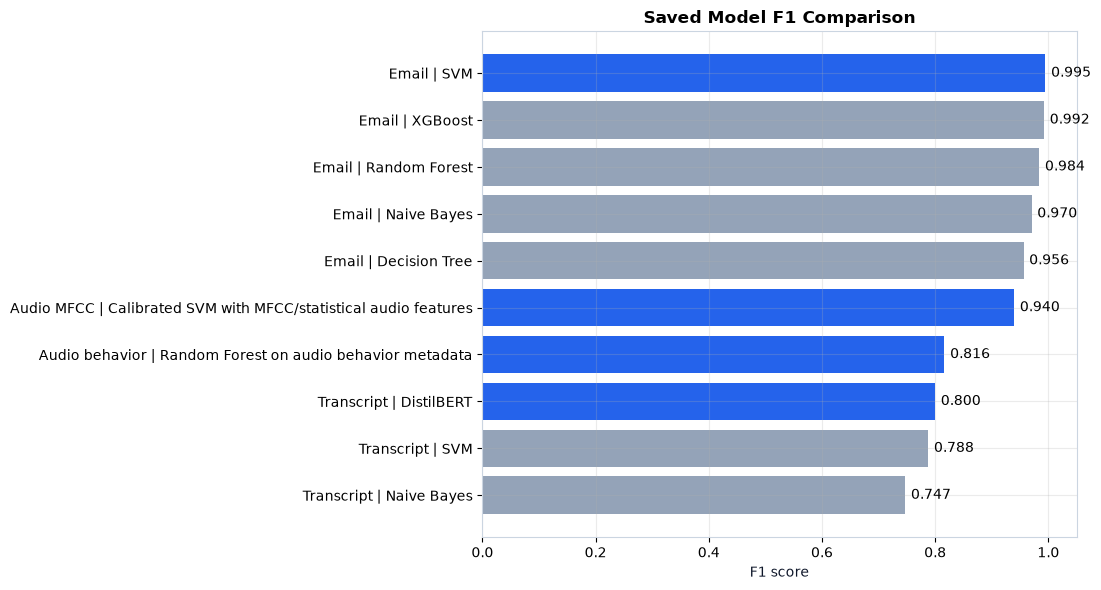

In [13]:
plot_df = metric_df.dropna(subset=["F1"]).copy()
plot_df["Label"] = plot_df["Channel"] + " | " + plot_df["Model"].astype(str)
plot_df = plot_df.sort_values("F1", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#2563EB" if selected == "Yes" else "#94A3B8" for selected in plot_df["Selected or recommended"]]
ax.barh(plot_df["Label"], plot_df["F1"], color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1 score")
ax.set_title("Saved Model F1 Comparison")
for index, value in enumerate(plot_df["F1"]):
    ax.text(value + 0.01, index, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()


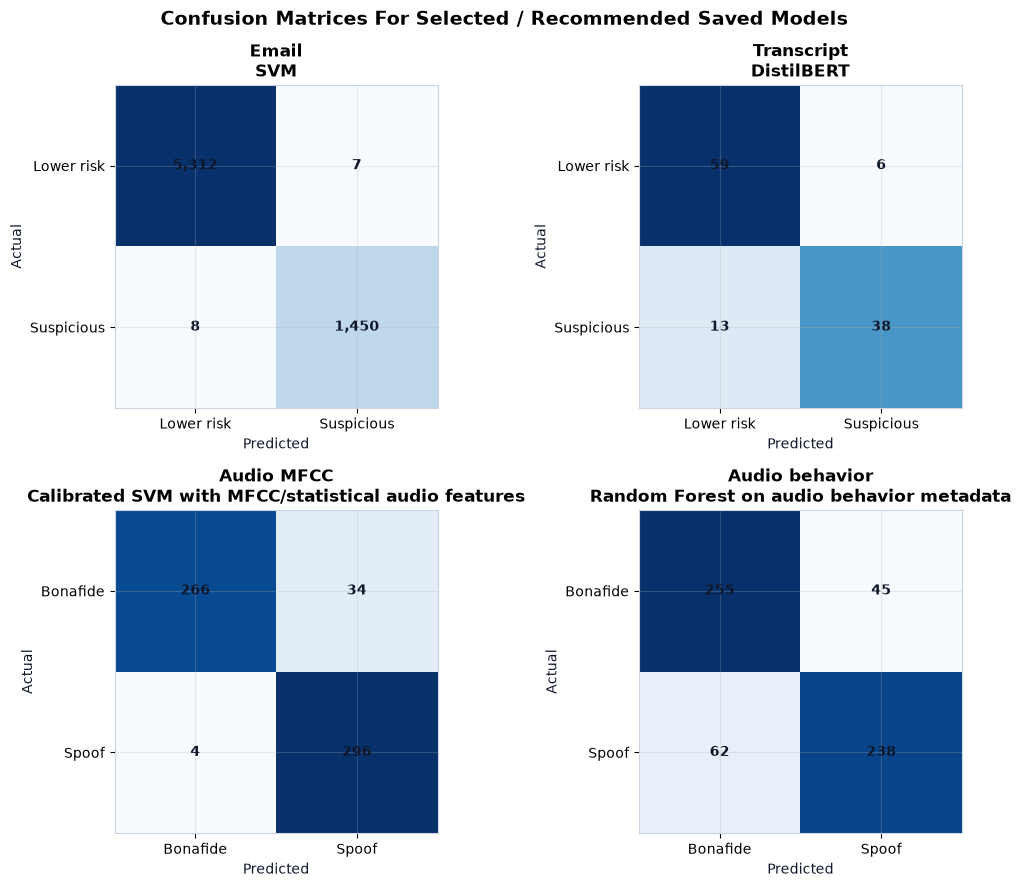

,Channel,Model,True negative,False positive,False negative,True positive,Why this matters
0,Email,SVM,5312,7,8,1450,False negatives are missed suspicious cases; false positives are false alarms.
1,Transcript,DistilBERT,59,6,13,38,False negatives are missed suspicious cases; false positives are false alarms.
2,Audio MFCC,Calibrated SVM with MFCC/statistical audio features,266,34,4,296,False negatives are missed suspicious cases; false positives are false alarms.
3,Audio behavior,Random Forest on audio behavior metadata,255,45,62,238,False negatives are missed suspicious cases; false positives are false alarms.


In [14]:
def selected_metric_records() -> list[dict[str, object]]:
    records: list[dict[str, object]] = []
    for channel, relative_path in METRIC_FILES.items():
        data = load_json(relative_path)
        if isinstance(data.get("models"), dict):
            selected_name = data.get("best_model") or data.get("recommended_model") or data.get("top_validation_model")
            models = data["models"]
            if selected_name not in models:
                selected_name = max(models, key=lambda name: models[name].get("f1", -1))
            metrics = models[selected_name]
            model_name = selected_name
        else:
            metrics = data.get("metrics", {})
            model_name = data.get("model", Path(relative_path).stem)
        records.append({"Channel": channel, "Model": model_name, "Metrics": metrics, "Metric file": relative_path})
    return records


selected_records = selected_metric_records()
cm_records = []
for record in selected_records:
    matrix = record["Metrics"].get("confusion_matrix")
    if matrix:
        tn, fp = matrix[0]
        fn, tp = matrix[1]
        cm_records.append({
            "Channel": record["Channel"],
            "Model": record["Model"],
            "True negative": tn,
            "False positive": fp,
            "False negative": fn,
            "True positive": tp,
            "Why this matters": "False negatives are missed suspicious cases; false positives are false alarms.",
        })

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, record in zip(axes.flatten(), selected_records):
    matrix = record["Metrics"].get("confusion_matrix")
    if not matrix:
        ax.axis("off")
        continue
    labels = ["Bonafide", "Spoof"] if "Audio" in record["Channel"] else ["Lower risk", "Suspicious"]
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks([0, 1], labels=labels)
    ax.set_yticks([0, 1], labels=labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{record['Channel']}\n{record['Model']}")
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f"{matrix[row][col]:,}", ha="center", va="center", color="#0F172A", fontweight="bold")
plt.suptitle("Confusion Matrices For Selected / Recommended Saved Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

display(pd.DataFrame(cm_records))


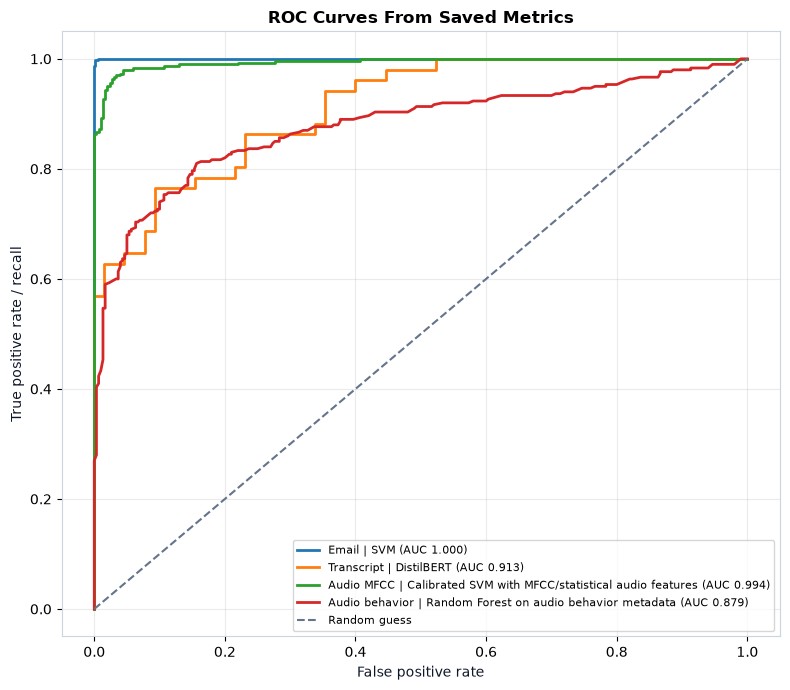

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
for record in selected_records:
    roc_curve = record["Metrics"].get("roc_curve") or {}
    fpr = roc_curve.get("fpr")
    tpr = roc_curve.get("tpr")
    auc_value = record["Metrics"].get("roc_auc")
    if fpr and tpr:
        ax.plot(fpr, tpr, linewidth=2, label=f"{record['Channel']} | {record['Model']} (AUC {auc_value:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#64748B", label="Random guess")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate / recall")
ax.set_title("ROC Curves From Saved Metrics")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


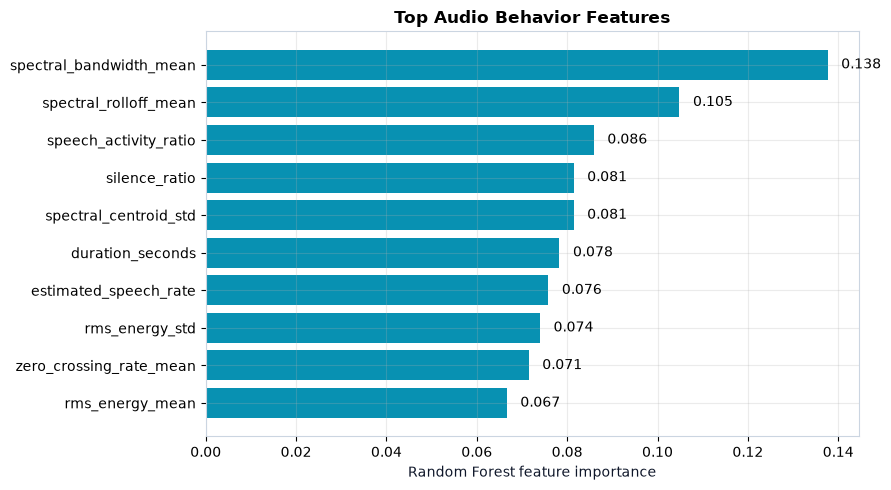

,feature,importance
0,spectral_bandwidth_mean,0.137654
1,spectral_rolloff_mean,0.104853
2,speech_activity_ratio,0.085896
3,silence_ratio,0.081432
4,spectral_centroid_std,0.081429
5,duration_seconds,0.078288
6,estimated_speech_rate,0.075828
7,rms_energy_std,0.073987
8,zero_crossing_rate_mean,0.071490
9,rms_energy_mean,0.066635


In [16]:
feature_importance_df = pd.DataFrame(audio_behavior_metrics.get("feature_importances", []))
if feature_importance_df.empty:
    display(Markdown("No audio behavior feature importance values were found."))
else:
    top_features = feature_importance_df.head(10).sort_values("importance", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top_features["feature"], top_features["importance"], color="#0891B2")
    ax.set_xlabel("Random Forest feature importance")
    ax.set_title("Top Audio Behavior Features")
    for index, value in enumerate(top_features["importance"]):
        ax.text(value + 0.003, index, f"{value:.3f}", va="center")
    plt.tight_layout()
    plt.show()
    display(feature_importance_df.head(10))


In [17]:
verification_gate_df = pd.DataFrame([
    {"Gate": "Core source files present", "Status": ready_label(all_status_pass(core_path_df)), "Evidence": f"{sum(core_path_df['Status'] == 'PASS')} of {len(core_path_df)} files found"},
    {"Gate": "Required functions present", "Status": ready_label(all_status_pass(function_df)), "Evidence": f"{sum(function_df['Status'] == 'PASS')} of {len(function_df)} functions found"},
    {"Gate": "Dashboard pages and tabs match final scope", "Status": ready_label(all_status_pass(dashboard_gate_df)), "Evidence": "2 pages and 3 detection tabs verified from source"},
    {"Gate": "Processed/demo datasets readable", "Status": ready_label(all_status_pass(data_readiness_df)), "Evidence": f"{sum(data_readiness_df['Status'] == 'PASS')} of {len(data_readiness_df)} CSVs readable"},
    {"Gate": "Training command wrappers present", "Status": ready_label((command_df["Wrapper exists"] == "PASS").all()), "Evidence": f"{sum(command_df['Wrapper exists'] == 'PASS')} of {len(command_df)} wrappers found"},
    {"Gate": "Model and metric artifacts available", "Status": "PASS" if (artifact_df["Status"] == "PASS").all() else "WARN", "Evidence": f"{sum(artifact_df['Status'] == 'PASS')} of {len(artifact_df)} artifacts present"},
    {"Gate": "Saved metric JSONs produce comparison rows", "Status": ready_label(not metric_df.empty), "Evidence": f"{len(metric_df)} model metric rows loaded"},
])
display(verification_gate_df)


,Gate,Status,Evidence
0,Core source files present,PASS,9 of 9 files found
1,Required functions present,PASS,10 of 10 functions found
2,Dashboard pages and tabs match final scope,PASS,2 pages and 3 detection tabs verified from source
3,Processed/demo datasets readable,PASS,7 of 7 CSVs readable
4,Training command wrappers present,PASS,8 of 8 wrappers found
5,Model and metric artifacts available,PASS,17 of 17 artifacts present
6,Saved metric JSONs produce comparison rows,PASS,10 model metric rows loaded


### 3.9 Phase 8: Model Deployment

#### 3.9.1 Report Generator Verification

This smoke test builds one small in-memory report from sample evidence. It does not save a report file to disk, but it proves that the report builder can generate the expected payloads from the current code path.


In [18]:
from src.reporting.report_builder import DEFAULT_RECOMMENDATION, DEFAULT_SECTIONS, build_preview, build_report

sample_evidence = [
    {"id": 1, "scan_type": "Email", "source_name": "demo_email.txt", "prediction": "Suspicious phishing attempt", "confidence": 94.2, "model_name": "Email SVM", "preview": "Urgent account verification and payment request.", "flags": ["urgent request", "credential request", "payment pressure"], "scanned_at": "2026-07-24T09:00:00"},
    {"id": 2, "scan_type": "Transcript", "source_name": "demo_call_transcript.txt", "prediction": "Suspicious scam script", "confidence": 83.5, "model_name": "Transcript DistilBERT", "preview": "Caller asks for OTP and warns account will be blocked.", "flags": ["OTP request", "authority pressure"], "scanned_at": "2026-07-24T09:05:00"},
    {"id": 3, "scan_type": "Phone", "source_name": "+60123456789", "prediction": "Unknown caller reputation", "confidence": 0, "model_name": "Phone reputation rules", "preview": "Carrier metadata only; caller identity unconfirmed.", "flags": ["Phone ownership unconfirmed"], "scanned_at": "2026-07-24T09:10:00"},
]

preview = build_preview(sample_evidence, DEFAULT_RECOMMENDATION, DEFAULT_SECTIONS)
report_rows = []
for report_format in ["TXT", "PDF", "DOCX"]:
    try:
        payload, filename, mime_type = build_report(report_format, sample_evidence, DEFAULT_RECOMMENDATION, DEFAULT_SECTIONS)
        report_rows.append({"Format": report_format, "Status": "PASS", "Filename": filename, "MIME type": mime_type, "Payload bytes": f"{len(payload):,}"})
    except Exception as exc:
        report_rows.append({"Format": report_format, "Status": "WARN", "Filename": "-", "MIME type": "-", "Payload bytes": "-", "Issue": f"{type(exc).__name__}: {exc}"})

report_smoke_df = pd.DataFrame(report_rows)
display(report_smoke_df)
display(Markdown("### Preview excerpt\n\n```text\n" + preview[:1200] + "\n```"))


,Format,Status,Filename,MIME type,Payload bytes
0,TXT,PASS,AIFDS_Report_20260725_011614.txt,text/plain,"4,495"
1,PDF,PASS,AIFDS_Report_20260725_011615.pdf,application/pdf,"140,583"
2,DOCX,PASS,AIFDS_Report_20260725_011616.docx,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"127,090"


### Preview excerpt

```text
AI-based Spam and Caller Fraud Detection System
AI Analysis Evidence Report
Generated: 2026-07-25 01:16:14 (Asia/Kuala_Lumpur, GMT+08:00)
Records included: 3

Investigation Summary
- Evidence selected: 3
- Email evidence: 1
- Transcript evidence: 1
- Audio evidence: 0
- Phone evidence: 1
- High concern: 2
- Needs review: 0
- Lower concern: 0
- Unknown: 1

Evidence Outcome Distribution
- High concern: 2
- Needs review: 0
- Lower concern: 0
- Unknown: 1

Selected Evidence Overview
1. Email | Source: demo_email.txt | Result: Suspicious phishing attempt | Risk/Confidence: 94.2% | Engine: Email SVM
2. Transcript | Source: demo_call_transcript.txt | Result: Suspicious scam script | Risk/Confidence: 83.5% | Engine: Transcript DistilBERT
3. Phone | Source: +60123456789 | Result: Unknown caller reputation | Risk/Confidence: N/A | Engine: Phone reputation rules

Individual Evidence Results

------------------------------------------------------------------------
Evidence 1 of 3 - Email
------------------------------------------------------------------------
Evidence type: Email
Source: demo_email.txt
Result: Suspicious phishing attempt
Risk/Confidence: 94.2%
Engine: Email SVM
Detected indica
```

#### 3.9.2 Reproducibility and Sharing

For sharing, export this notebook after all cells run successfully. HTML is usually the easiest reviewer format because it preserves charts and tables without asking the reader to run code.

Suggested command from the project root:

```bash
jupyter nbconvert --to html --execute notebooks/00_final_prototype_evidence_notebook.ipynb
```

For a formal archive, keep the notebook, exported HTML/PDF, metric JSON files, and referenced source files together. Do not detach the notebook from the repo and then claim source traceability, because the file links and excerpts need project context.


In [19]:
reproducibility_checks = [
    ("Notebook has one top-level title", True),
    ("Notebook detects project root", ROOT.exists()),
    ("Core source files are present", all_status_pass(core_path_df)),
    ("Dashboard scope gate passed", all_status_pass(dashboard_gate_df)),
    ("Processed/demo datasets are readable", all_status_pass(data_readiness_df)),
    ("Training command wrappers are documented", (command_df["Wrapper exists"] == "PASS").all()),
    ("Split and feature audit exists", not split_audit_df.empty and not feature_audit_df.empty),
    ("Metric rows loaded", not metric_df.empty),
    ("Charts generated from saved metrics/data", True),
    ("Report builder smoke test attempted", not report_smoke_df.empty),
    ("No entire Python files pasted", True),
]
reproducibility_df = pd.DataFrame([
    {"Check": check, "Status": "PASS" if status else "WARN"}
    for check, status in reproducibility_checks
])
display(reproducibility_df)


,Check,Status
0,Notebook has one top-level title,PASS
1,Notebook detects project root,PASS
2,Core source files are present,PASS
3,Dashboard scope gate passed,PASS
4,Processed/demo datasets are readable,PASS
5,Training command wrappers are documented,PASS
6,Split and feature audit exists,PASS
7,Metric rows loaded,PASS
8,Charts generated from saved metrics/data,PASS
9,Report builder smoke test attempted,PASS


#### 3.9.3 Automated Testing Evidence and API-Key Safety

The `tests/` folder supports the final prototype evidence by checking the parts that are difficult for a reviewer to see from the dashboard alone: model/runtime loading, explanation helpers, audio handling, phone-provider setup, API-key handling, and report-adjacent evidence safety.

For phone APIs, testing must stay offline and mocked. The purpose is not to spend live Veriphone.io or PenipuMY credits during validation. Instead, the tests prove that the dashboard can detect configured keys, label missing or rejected keys clearly, normalize provider failures into reviewer-friendly statuses, and avoid exposing raw keys in diagnostics.

**What this proves for presentation:**

- The Email, Transcript, Audio, and Phone workflows are not only described in markdown; they have source-level checks.
- API-key setup can be explained transparently: dashboard session input is the simplest demo path, while environment variables and Streamlit secrets are optional deployment paths.
- Phone records remain provider-pulled evidence plus deterministic rules, not locally trained phone-risk values.
- The report generator should receive user-visible evidence and provider statuses, not hidden credentials.


In [ ]:
import ast

TEST_DOCUMENTATION = {
    "tests/test_text_classifier.py": ("Text model runtime", "Email/message classifier artifacts load with nested estimators constrained for runtime stability."),
    "tests/test_audio_classifier.py": ("Audio model runtime", "Audio classifier artifacts load with nested estimators constrained for runtime stability."),
    "tests/test_live_audio_analysis.py": ("Live/uploaded audio analysis", "Uploaded audio, Whisper transcription, silence gating, and combined evidence scoring behave as expected."),
    "tests/test_internal_capture.py": ("Internal capture support", "System/device capture helpers identify usable audio sources and handle audio conversion safely."),
    "tests/test_system_check.py": ("System diagnostics", "Capture checks distinguish silence/signal and write diagnostic evidence."),
    "tests/test_explainability.py": ("Text explainability", "Domain, sender, suspicious phrase, and legitimate-context indicators are traceable."),
    "tests/test_transcript_preprocessor.py": ("Transcript preparation", "Suspicious labels and unlabeled rows are prepared safely before model training."),
    "tests/test_veriphone_client.py": ("Veriphone.io client", "Veriphone.io request headers, lookup mode, provider error handling, and key redaction are covered."),
    "tests/test_penipumy_client.py": ("PenipuMY client", "PenipuMY request headers, normalized query formatting, missing key handling, and API errors are covered."),
    "tests/test_phone_provider_keys.py": ("Phone API-key resolution", "Session input, environment variables, Streamlit secrets, missing keys, and masked metadata are covered."),
    "tests/test_phone_provider_diagnostics.py": ("Phone provider diagnostics", "Provider status mapping, hidden key values, missing keys, and authentication failures are covered."),
}


def test_functions(relative_path: str) -> list[str]:
    path = project_path(relative_path)
    if not path.exists():
        return []
    tree = ast.parse(path.read_text(encoding="utf-8"), filename=relative_path)
    return sorted(
        node.name
        for node in ast.walk(tree)
        if isinstance(node, ast.FunctionDef) and node.name.startswith("test_")
    )


def test_classes(relative_path: str) -> list[str]:
    path = project_path(relative_path)
    if not path.exists():
        return []
    tree = ast.parse(path.read_text(encoding="utf-8"), filename=relative_path)
    return sorted(node.name for node in ast.walk(tree) if isinstance(node, ast.ClassDef))


def test_file_has_mocked_api_behavior(relative_path: str) -> bool:
    text = read_text(relative_path) if project_path(relative_path).exists() else ""
    return any(marker in text for marker in ["Mock", "patch", "fake_requests", "FakeResponse"])


test_rows = []
for relative_path in sorted(path.relative_to(ROOT).as_posix() for path in project_path("tests").glob("test_*.py")):
    purpose, feature = TEST_DOCUMENTATION.get(relative_path, ("Additional regression coverage", "Supports source-level validation."))
    functions = test_functions(relative_path)
    test_rows.append({
        "Test file": relative_path,
        "Purpose": purpose,
        "Feature proved": feature,
        "Test functions": len(functions),
        "Representative checks": ", ".join(functions[:3]) + (" ..." if len(functions) > 3 else ""),
        "Status": "PASS" if functions else "REVIEW",
    })

test_audit_df = pd.DataFrame(test_rows)
display(test_audit_df)

api_key_safety_df = pd.DataFrame([
    {
        "Safety check": "Dashboard session key path",
        "Proof file": "tests/test_phone_provider_keys.py",
        "Expected outcome": "A pasted session key overrides environment/secrets and is displayed only as masked metadata.",
    },
    {
        "Safety check": "Optional deployment key paths",
        "Proof file": "tests/test_phone_provider_keys.py",
        "Expected outcome": "VERIPHONE_API_KEY, PENIPUMY_API_KEY, PENIPU_API_KEY, and Streamlit secret sections are recognized.",
    },
    {
        "Safety check": "Missing key behavior",
        "Proof file": "tests/test_phone_provider_keys.py; tests/test_phone_provider_diagnostics.py; tests/test_penipumy_client.py",
        "Expected outcome": "Missing provider credentials become clear not-configured diagnostics instead of confusing backend failures.",
    },
    {
        "Safety check": "Provider authentication/credit errors",
        "Proof file": "tests/test_veriphone_client.py; tests/test_phone_provider_diagnostics.py; tests/test_penipumy_client.py",
        "Expected outcome": "Rejected keys, insufficient credits, rate limits, timeouts, and provider errors are classified for reviewer-friendly display.",
    },
    {
        "Safety check": "No live API use in tests",
        "Proof file": "tests/test_veriphone_client.py; tests/test_penipumy_client.py",
        "Expected outcome": "HTTP calls are mocked, so tests do not spend live credits, require real keys, or depend on provider availability.",
    },
])
display(api_key_safety_df)

testing_gate_df = pd.DataFrame([
    {"Gate": "Automated tests are present", "Status": ready_label(len(test_audit_df) > 0), "Evidence": f"{len(test_audit_df)} test files detected"},
    {"Gate": "Phone API-key tests are present", "Status": ready_label(project_path("tests/test_phone_provider_keys.py").exists()), "Evidence": "Session/env/secrets and missing-key paths documented by tests"},
    {"Gate": "Phone provider diagnostics are present", "Status": ready_label(project_path("tests/test_phone_provider_diagnostics.py").exists()), "Evidence": "Diagnostic status mapping and hidden key-value behavior documented by tests"},
    {"Gate": "Both active phone providers have client coverage", "Status": ready_label(project_path("tests/test_veriphone_client.py").exists() and project_path("tests/test_penipumy_client.py").exists()), "Evidence": "Veriphone.io and PenipuMY client behavior checked with mocked responses"},
    {"Gate": "Phone API tests use mocked provider responses", "Status": ready_label(all(test_file_has_mocked_api_behavior(path) for path in ["tests/test_veriphone_client.py", "tests/test_penipumy_client.py"])), "Evidence": "No live provider calls or real API keys required for automated validation"},
])
display(testing_gate_df)


### 3.10 Reviewer Explanation and Limitations

#### 3.10.1 Vigilator Briefing and Boundaries

Use two explanation layers: a professional technical explanation, then a plain-language explanation.

**Technical explanation:** AI-FDS receives evidence from email/message text, call transcript or uploaded audio, and phone-number checks. Each channel uses the model or evidence strategy appropriate for that input. Text models produce probabilities and labels. Audio models produce voice-authenticity concern signals. Phone checks collect provider evidence, including Veriphone.io metadata and PenipuMY reputation reports, then apply deterministic concern rules. Results are saved into local evidence history, then the report generator packages selected evidence into TXT/PDF/DOCX outputs.

**Plain-language explanation:** The dashboard does not magically decide guilt or safety. It highlights warning signs, shows which evidence caused concern, and prepares a clear report so a trained human reviewer can confirm, challenge, or escalate the case.

**Boundary statement:** AI-FDS is an educational capstone prototype for scam-awareness support. It is not telecom caller-ID verification, legal evidence, a forensic voice-authentication system, or an automatic blocking system.

**Known limitations to state clearly:**

- Predictions can be wrong and must be verified by a human reviewer.
- Email and transcript models depend on the processed training data and saved validation metrics.
- High email metrics may reflect the current dataset mix and should not be presented as universal real-world accuracy.
- Transcript results can be sensitive to short text, ambiguous wording, and class coverage in the training data.
- Whisper transcription can be inaccurate with noise, accents, overlapping speakers, or missing FFmpeg/audio dependencies.
- Audio spoof detection is an educational signal, not forensic speaker verification.
- Phone provider metadata can be unavailable, rate-limited, or incomplete. Unknown does not mean safe.
- Carrier metadata does not prove who is holding the phone or whether the caller is legitimate.
- The report generator summarizes evidence; it does not create legal proof.


In [20]:
briefing_rows = [
    {"Audience question": "What does the dashboard do?", "Professional answer": "It collects scam-risk evidence across message text, call transcript/audio, and phone provider evidence, then preserves selected evidence in a report generator.", "Plain answer": "It gathers warning signs from different places and helps a reviewer prepare a clean report."},
    {"Audience question": "Why are there different AI models?", "Professional answer": "Each data type needs a different representation: TF-IDF/transformers for text, MFCC/statistical features for audio, and API-derived provider evidence with deterministic scoring for phone numbers.", "Plain answer": "A message, a voice recording, and a phone number are different kinds of evidence, so they should not all be judged the same way."},
    {"Audience question": "What is 80/20 training?", "Professional answer": "For email and transcript models, 80 percent of labeled rows train the model and 20 percent are held out for evaluation using stratified splitting.", "Plain answer": "Most examples teach the model; a smaller unseen portion checks whether it learned useful patterns."},
    {"Audience question": "Why is audio different?", "Professional answer": "Audio uses an ASVspoof train/dev split and MFCC/statistical features because speech authenticity is a signal-processing task.", "Plain answer": "Voice evidence is not normal text, so it needs audio features and a separate validation set."},
    {"Audience question": "Can the model be wrong?", "Professional answer": "Yes. The metrics describe validation performance on saved data, and all high-stakes decisions still require human verification.", "Plain answer": "Yes. The system is a helper, not the final judge."},
    {"Audience question": "What is the report generator for?", "Professional answer": "It converts selected scan history into structured TXT, PDF, or DOCX evidence reports with summaries, explanations, risk notes, and recommendations.", "Plain answer": "It turns useful scan results into a shareable report."},
]

demo_script_df = pd.DataFrame([
    {"Step": 1, "Demo action": "Open Detection Center", "What to say": "This is the main analysis page. It contains the three evidence channels."},
    {"Step": 2, "Demo action": "Show Email tab", "What to say": "Email/message text is checked by trained text classifiers and suspicious phrase indicators."},
    {"Step": 3, "Demo action": "Show Transcript/Audio tab", "What to say": "Transcript text uses text models; uploaded audio adds voice-authenticity and speech-quality signals."},
    {"Step": 4, "Demo action": "Show Phone tab", "What to say": "Phone checks pull Veriphone.io carrier metadata and PenipuMY reputation reports, then use transparent evidence-concern rules rather than a trained phone model."},
    {"Step": 5, "Demo action": "Open AI Report Generator", "What to say": "Saved evidence can be selected and exported as TXT, PDF, or DOCX for review."},
    {"Step": 6, "Demo action": "End with limitations", "What to say": "The prototype supports scam-awareness review. It does not replace legal, telecom, or forensic verification."},
])

display(Markdown("### Q&A briefing"))
display(pd.DataFrame(briefing_rows))
display(Markdown("### Short live demo script"))
display(demo_script_df)


### Q&A briefing

,Audience question,Professional answer,Plain answer
0,What does the dashboard do?,"It collects scam-risk evidence across message text, call transcript/audio, and phone provider evidence, then preserves selected evidence...",It gathers warning signs from different places and helps a reviewer prepare a clean report.
1,Why are there different AI models?,"Each data type needs a different representation: TF-IDF/transformers for text, MFCC/statistical features for audio, and API-derived prov...","A message, a voice recording, and a phone number are different kinds of evidence, so they should not all be judged the same way."
2,What is 80/20 training?,"For email and transcript models, 80 percent of labeled rows train the model and 20 percent are held out for evaluation using stratified ...",Most examples teach the model; a smaller unseen portion checks whether it learned useful patterns.
3,Why is audio different?,Audio uses an ASVspoof train/dev split and MFCC/statistical features because speech authenticity is a signal-processing task.,"Voice evidence is not normal text, so it needs audio features and a separate validation set."
4,Can the model be wrong?,"Yes. The metrics describe validation performance on saved data, and all high-stakes decisions still require human verification.","Yes. The system is a helper, not the final judge."
5,What is the report generator for?,"It converts selected scan history into structured TXT, PDF, or DOCX evidence reports with summaries, explanations, risk notes, and recom...",It turns useful scan results into a shareable report.


### Short live demo script

,Step,Demo action,What to say
0,1,Open Detection Center,This is the main analysis page. It contains the three evidence channels.
1,2,Show Email tab,Email/message text is checked by trained text classifiers and suspicious phrase indicators.
2,3,Show Transcript/Audio tab,Transcript text uses text models; uploaded audio adds voice-authenticity and speech-quality signals.
3,4,Show Phone tab,"Phone checks pull Veriphone.io carrier metadata and PenipuMY reputation reports, then use transparent evidence-concern rules rather than a trai..."
4,5,Open AI Report Generator,"Saved evidence can be selected and exported as TXT, PDF, or DOCX for review."
5,6,End with limitations,"The prototype supports scam-awareness review. It does not replace legal, telecom, or forensic verification."
